# **CMP-7023B Data Mining - Preliminary Data Analysis**
## **100318577**

#### Aim: Perform the initial steps of the Knowledge Discovery in Databases (KDD) process on the EmpData.csv dataset, which contains survey data that could aid in understanding the employability and career prospects of students enrolled in a Data Science programme.

In [1]:
# PACKAGES ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Suppress warnings
import warnings # reduce cluttered output
warnings.filterwarnings("ignore")

## 1. Load EmpData

In [2]:
# LOAD DATA
emp = pd.read_csv("EmpData.csv")

print("Data Info.")
print(emp.info())

Data Info.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26713 entries, 0 to 26712
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      26713 non-null  object 
 1   Age            26713 non-null  object 
 2   Industry       26643 non-null  object 
 3   Title          26713 non-null  object 
 4   Context        6913 non-null   object 
 5   Salary         26713 non-null  int64  
 6   Surplus        19762 non-null  float64
 7   Currency       26713 non-null  object 
 8   Other          201 non-null    object 
 9   Income_info    2888 non-null   object 
 10  Country        26713 non-null  object 
 11  State_USA      21931 non-null  object 
 12  City           26636 non-null  object 
 13  Experience     26713 non-null  object 
 14  In_Field       26713 non-null  object 
 15  Education      26502 non-null  object 
 16  Gender         26552 non-null  object 
 17  Race           26549 non-null  object 


________________________________________________________________________________________________________________________________________

## 2. Data Dictionary for EmpData

[Disclaimer]: The following code for Data Dictonary generation was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

In [3]:
# Summarize each column with unique values
unique_summary = {col: emp[col].unique().tolist() for col in emp.columns}

# Convert the unique summary to a dataframe
unique_summary_df = pd.DataFrame([
    {'Variable': col, 'Unique_Values': ', '.join(map(str, unique_summary[col]))}
    for col in emp.columns
])

# Print the unique results summary in a table format
print('Unique Summary')
print(unique_summary_df)
print('__________________________________________________________________________________________')
print(emp.describe().transpose())
print('__________________________________________________________________________________________')
print(emp.info())
print('__________________________________________________________________________________________')

Unique Summary
         Variable                                      Unique_Values
0       Timestamp  4/27/2021 11:02:10, 4/27/2021 11:02:22, 4/27/2...
1             Age  25-34, 45-54, 35-44, 18-24, 65 or over, 55-64,...
2        Industry  Education (Higher Education), Computing or Tec...
3           Title  Research and Instruction Librarian, Change & I...
4         Context  nan, High school, FT, Data developer/ETL Devel...
5          Salary  55000, 54600, 34000, 62000, 60000, 50000, 1120...
6         Surplus  0.0, 4000.0, nan, 3000.0, 7000.0, 10000.0, 500...
7        Currency  USD, GBP, CAD, EUR, AUD/NZD, Other, CHF, ZAR, ...
8           Other  nan, INR, Peso Argentino, $76,302.34, My bonus...
9     Income_info  nan, I work for a Charter School, Commission b...
10        Country  United States, United Kingdom, US, USA, Canada...
11      State_USA  Massachusetts, nan, Tennessee, Wisconsin, Sout...
12           City  Boston, Cambridge, Chattanooga, Milwaukee, Gre...
13     Experience  

In [4]:
# Define column descriptions
descriptions = {
    'Timestamp': 'The date and time when the data was recorded',
    'Age': 'Age group of individuals',
    'Industry': 'Industry of employment',
    'Title': 'Job title of individuals',
    'Context': 'Work context',
    'Salary': 'Annual salary in USD',
    'Surplus': 'Surplus amount in USD',
    'Currency': 'Currency of salary',
    'Other': 'Other relevant information',
    'Income_info': 'Additional income information',
    'Country': 'Country of residence',
    'State_USA': 'State in the USA',
    'City': 'City of residence',
    'Experience': 'Years of experience',
    'In_Field': 'Years of experience in the field',
    'Education': 'Highest educational qualification',
    'Gender': 'Gender of individuals',
    'Race': 'Race or ethnicity of individuals',
    'Qualification': 'Qualification level'
}

# Define data types
data_types = {col: str(emp[col].dtype) for col in emp.columns}

# Combine all information into a data dictionary [See Disclaimer]
data_dictionary_df = pd.DataFrame({
    'Variable': emp.columns,
    'Data Type': [data_types[col] for col in emp.columns],
    'Description': [descriptions[col] for col in emp.columns],
    'Unique_Values': [', '.join(map(str, emp[col].unique())) for col in emp.columns]
})

# Print the data dictionary
print(data_dictionary_df.head())#to_string(index=False))

    Variable Data Type                                   Description  \
0  Timestamp    object  The date and time when the data was recorded   
1        Age    object                      Age group of individuals   
2   Industry    object                        Industry of employment   
3      Title    object                      Job title of individuals   
4    Context    object                                  Work context   

                                       Unique_Values  
0  4/27/2021 11:02:10, 4/27/2021 11:02:22, 4/27/2...  
1  25-34, 45-54, 35-44, 18-24, 65 or over, 55-64,...  
2  Education (Higher Education), Computing or Tec...  
3  Research and Instruction Librarian, Change & I...  
4  nan, High school, FT, Data developer/ETL Devel...  


| Variable     | Data Type | Description                                  | Example Values                                                   |
|--------------|-----------|----------------------------------------------|------------------------------------------------------------------|
| Timestamp    | String    | The date and time when the data was recorded | 4/27/2021 11:02:10, 4/27/2021 11:02:22, 4/27/2021 11:02:33       |
| Age          | String    | Age group of individuals                     | 18-24, 25-34, 35-44, 45-54, 55-64, 65 or over                    |
| Industry     | String    | Industry of employment                       | Computing or Technology, Education (Higher Education)            |
| Title        | String    | Job title of individuals                     | Change & Innovation, Research and Instruction Librarian          |
| Context      | String    | Work context                                 | Data developer/ETL Developer, FT, High school, nan               |
| Salary       | Float     | Annual salary in USD                         | 34000, 50000, 54600, 55000, 60000, 62000, 112000                 |
| Surplus      | Float     | Surplus amount in USD                        | 0.0, 3000.0, 4000.0, 500.0, 7000.0, 10000.0, nan                 |
| Currency     | String    | Currency of salary                           | AUD/NZD, CAD, CHF, EUR, GBP, Other, USD, ZAR                     |
| Other        | String    | Other relevant information                   | $76,302.34, INR, My bonus..., Peso Argentino, nan                |
| Income_info  | String    | Additional income information                | Commission based..., I work for a Charter School, nan            |
| Country      | String    | Country of residence                         | Canada, United Kingdom, United States, US, USA                   |
| State_USA    | String    | State in the USA                             | Massachusetts, South..., Tennessee, Wisconsin, nan               |
| City         | String    | City of residence                            | Boston, Cambridge, Chattanooga, Gre..., Milwaukee                |
| Experience   | String    | Years of experience                          | 2-4 years, 5-7 years, 8-10 years, 21-30 years                    |
| In_Field     | String    | Years of experience in the field             | 2-4 years, 5-7 years, 11-20 years, 21-30 years                   |
| Education    | String    | Highest educational qualification            | College degree, Master degree, PhD, Some..., nan                 |
| Gender       | String    | Gender of individuals                        | Man, Non-binary, Other or prefer not to say, Woman, nan          |
| Race         | String    | Race or ethnicity of individuals             | Hispanic, Latino or Spanish origin, White, nan                   |
| Qualification| Float     | Qualification level                          | 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, nan                                |


________________________________________________________________________________________________________________________________________

## Catigorical and Continious variables

In [5]:
CATEGORICAL_COLUMNS = ["Industry", "Title", "Context", "Currency", "Other", "Income_info", "Country", 
                       "State_USA", "City", "Experience", "In_Field", "Education", "Gender", "Race"]
CONTINUOUS_COLUMNS = ["Salary", "Surplus", "Qualification"]

print(CATEGORICAL_COLUMNS)
print(CONTINUOUS_COLUMNS)

['Industry', 'Title', 'Context', 'Currency', 'Other', 'Income_info', 'Country', 'State_USA', 'City', 'Experience', 'In_Field', 'Education', 'Gender', 'Race']
['Salary', 'Surplus', 'Qualification']


## Descriptive statistics

[Disclaimer]: The code for StasNum was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

In [6]:
# Descriptive statistics for continuous variables
emp['Qualification'] = emp['Qualification'].round(0) # Round 'Qualification' column to 0 decimal places

# Round 'Salary' and 'Surplus' columns to 2 decimal places
emp['Salary'] = emp['Salary'].round(2)
emp['Surplus'] = emp['Surplus'].round(2)

# Descriptive statistics for continuous variables
Stats= emp[CONTINUOUS_COLUMNS].describe()

# Descriptive statistics for continuous variables
for column in CONTINUOUS_COLUMNS:
    Stats.loc['median', column] = emp[column].median()
    Stats.loc['missing', column] = emp[column].isnull().sum()

# Format the statistics to avoid showing .00 and display 0 for zero values [See disclaimer]
StatsNum = Stats.applymap(lambda x: '{:.2f}'.format(x).rstrip('0').rstrip('.') if x != 0 else '0')

print(StatsNum)

              Salary    Surplus Qualification
count          26713      19762         26502
mean       374952.85    18353.1          3.72
std      37126077.97  854895.36           1.2
min                0          0             1
25%            54000          0             3
50%            75000       2000             3
75%           109000      10000             5
max       6000070000  120000000             6
median         75000       2000             3
missing            0       6951           211


________________________________________________________________________________________________________________________________________

## 3. Data Cleaning
#### **Clean the column names and select relevant variables for further analysis.**

The selection of variables in the dataset `emp2` aligns directly with the aim of investigating the employability and career prospects of students enrolled in a Data Science program. Below is a detailed rationale for excluding variables not included in further analysis. Focusing solely on variables directly relevant to the aim makes the analysis more targeted.

1. **Exclusion of Demographic Variables**
   - Variables such as `race`, `country`, and `city` are excluded as they are not central to the specific investigation of employability and career prospects. While these variables provide contextual and demographic information, they do not contribute directly to understanding key employability metrics unless the research explicitly aims to explore geographic or racial disparities in employment outcomes.

2. **Exclusion of Financial Variables**
   - Columns such as `surplus`, `currency`, and `income_info` have been excluded as their relevance is peripheral to the stated aim. For instance:
     `surplus` and other financial indicators are more closely related to personal financial stability than to employability outcomes.
     - `currency` may introduce unnecessary complexity into the analysis without significantly contributing to insights into employability.
     - `income_info` likely pertains to broader economic factors and is less pertinent to individual career trajectories.

3. **Exclusion of Miscellaneous Variables**
   - Variables such as `state_usa` and `other` have been omitted due to their limited relevance. 
     - `state_usa` is geographically specific and does not provide meaningful insights unless the focus is on employment outcomes in a particular region.
     - `other` likely represent unstructured or non-standardized data, which may add noise rather than value to the analysis.

4. **Avoidance of Redundancy**
   - Variables such as `qualification` are excluded to eliminate redundancy, particularly if their content overlaps with the information captured in `education`. This ensures that the analysis remains streamlined and avoids duplicating data representations.

5. **Alignment with Research Objectives**
   - The chosen variables—`age`, `industry`, `title`, `salary`, `experience`, `in_field`, `education`, and `gender`—are directly relevant to the investigation as they capture critical factors influencing employability. 
     - `age` reflects the stage of career development.
     - `industry` and `title` indicate the sector and specific employment roles.
     - `salary` is a key indicator of career success and employability.
     - `experience` and `education` are widely recognized as determinants of employability.
     - `in_field` explores the alignment between education and current roles.
     - `gender` facilitates analysis of potential disparities in employability outcomes.

In [7]:
# Clean column names and select relevant columns for investigation
emp.columns = emp.columns.str.lower().str.replace(' ', '_') # Capital to lowercase
emp2 = emp[['age', 'industry', 'title', 'salary', 'experience', 'in_field', 'education', 'gender']]

print("Column names.")
print(emp2.columns)
print("_________________________________________________________________________________")
print("Data Info.")
print(emp2.info())

Column names.
Index(['age', 'industry', 'title', 'salary', 'experience', 'in_field',
       'education', 'gender'],
      dtype='object')
_________________________________________________________________________________
Data Info.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26713 entries, 0 to 26712
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         26713 non-null  object
 1   industry    26643 non-null  object
 2   title       26713 non-null  object
 3   salary      26713 non-null  int64 
 4   experience  26713 non-null  object
 5   in_field    26713 non-null  object
 6   education   26502 non-null  object
 7   gender      26552 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.6+ MB
None


________________________________________________________________________________________________________________________________________

## Missing data

Identification and addressing missing data in object-type columns by replacing gaps with the mode, the most frequent value in the dataset to maintain the integrity of categorical data by preserving common patterns within the columns, while offering transparency regarding any residual data issues for further analysis.

[Disclaimer]: The code highlighted was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

In [8]:
# Check for missing data
missing_data = emp2.isnull().sum()
missing_percentage = (missing_data / len(emp2)) * 100

# Create a DataFrame to display the missing data information
missing_data_emp2 = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percentage})

# Format the 'Percentage' column to display as percentages with '%' sign [see disclaimer]
missing_data_emp2['Percentage'] = missing_data_emp2['Percentage'].apply(lambda x: f"{x:.1f}") 

# Filter and sort the DataFrame
missing_data_emp2 = missing_data_emp2[missing_data_emp2['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

# Display the missing data information
missing_data_emp2

,Missing Values,Percentage
education,211,0.8
gender,161,0.6
industry,70,0.3


In [9]:
# Replace missing values in object columns with their mode
for col in emp2.select_dtypes(include='object').columns:
    emp2[col] = emp2[col].fillna(emp2[col].mode()[0])

# Check for missing data
missing_data2 = emp2.isnull().sum()
missing_percentage2 = (missing_data2 / len(emp2)) * 100

# Create a DataFrame to display the missing data information
missing_data2 = pd.DataFrame({'Missing Values': missing_data2, 'Percentage': missing_percentage2})

# Ensure that columns with zero missing values are included and formatted as '0' and '0%' [See disclaimer]
missing_data2['Missing Values'] = missing_data2['Missing Values'].apply(lambda x: int(x))  # Ensure integers for 0
missing_data2['Percentage'] = missing_data2['Percentage'].apply(lambda x: f"{x:.0f}%" if x != 0 else "0%")

# Sort the DataFrame (optional, but keeps it consistent)
missing_data2 = missing_data2.sort_values(by='Percentage', ascending=False)

# Check all columns have no missing values
missing_data2


,Missing Values,Percentage
age,0,0%
industry,0,0%
title,0,0%
salary,0,0%
experience,0,0%
in_field,0,0%
education,0,0%
gender,0,0%


________________________________________________________________________________________________________________________________________

## 4. Visualize the distribution of age groups

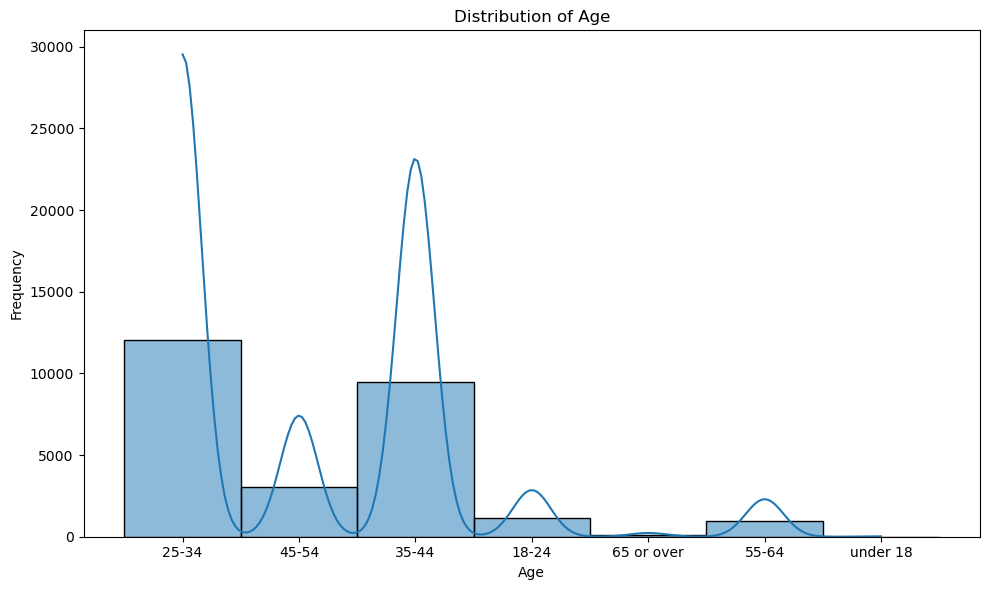

In [10]:
# Create a figure and axis
plt.figure(figsize=(10, 6))

# Plot the distribution of Age
sns.histplot(emp['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Display the plot
plt.tight_layout()
plt.show()

Notably, the 25-34 and 35-44 age ranges exhibit pronounced peaks, indicating a substantial representation of individuals within these cohorts. Conversely, there is a marked decline in participant numbers for the younger demographic (under 24) and the older population (55 and above), suggesting a relative scarcity of respondents in these categories.

________________________________________________________________________________________________________________________________________

## 5. Outliers in salary
The following code introduces a reusable Python function, `analyze_salary`, tailored to process the `salary` column in the `emp2` DataFrame.

**Purpose**:
- Calculates key salary statistics: minimum, maximum, and mean values.
- Identifies outliers using the Interquartile Range (IQR) method.

**Features**:
Incorporates a nested `format_salary` function to improve readability by:
- Converting large numbers into intuitive formats (e.g., millions or thousands).
- Displaying smaller values with two decimal places.
Filters outliers by identifying data points outside the range `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` to isolate anomalies.

**Output**:
- Displays formatted salary statistics for better presentation.
- Outputs a preview of the rows containing outliers to facilitate anomaly inspection.

**Benefits**:
- Centralizes calculations, formatting, and outlier detection into a single cohesive function.
- Enhances clarity and reusability, making it suitable for broader data analysis tasks.


In [11]:
# Function to calculate salary statistics and identify outliers
def analyze_salary(dataframe, salary_column, age_column):
    # Calculate basic statistics
    min_salary = dataframe[salary_column].min()
    max_salary = dataframe[salary_column].max()
    mean_salary = dataframe[salary_column].mean()

    # Format and print statistics
    def format_salary(value):
        if value >= 1000000:
            return f'{value/1000000:.1f} million' # show in output as million
        elif value >= 1000:
            return f'{value/1000:.0f}K' # show in output as K to represent $1000
        else:
            return f'{value:.2f}'
    
    print(f"Minimum Salary: {format_salary(min_salary)}")
    print(f"Maximum Salary: {format_salary(max_salary)}")
    print(f"Mean Salary: {format_salary(mean_salary)}")

    print("____________________________________")
    print(" ")

    # Calculate median, mean, and standard deviation for salary per age group
    grouped_stats = dataframe.groupby(age_column)[salary_column].agg(['median', 'mean', 'std']).round(2)
    grouped_stats['median'] = grouped_stats['median'].apply(format_salary)
    grouped_stats['mean'] = grouped_stats['mean'].apply(format_salary)
    grouped_stats['std'] = grouped_stats['std'].apply(format_salary)
    
    print("Salary Statistics per Age Group:")
    print(grouped_stats.to_string())

    print("____________________________________")
    print(" ")

    # Identify outliers using IQR (Inter Quatile Range)
    Q1 = dataframe[salary_column].quantile(0.25)
    Q3 = dataframe[salary_column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = dataframe[(dataframe[salary_column] < (Q1 - 1.5 * IQR)) | (dataframe[salary_column] > (Q3 + 1.5 * IQR))]
    
    print("Identified Outliers:")
    print(outliers[[salary_column]].head())

# print
analyze_salary(emp2, 'salary', 'age')

Minimum Salary: 0.00
Maximum Salary: 6000.1 million
Mean Salary: 375K
____________________________________
 
Salary Statistics per Age Group:
           median         mean            std
age                                          
18-24         50K  5.2 million  175.9 million
25-34         70K         120K    1.9 million
35-44         85K         126K    1.4 million
45-54         88K         106K           175K
55-64         83K  1.0 million   28.4 million
65 or over    92K         114K           204K
under 18      42K         552K    1.6 million
____________________________________
 
Identified Outliers:
     salary
31   230000
44   200850
99   196000
169  400000
181  215000


### **Plotting outliers**

[Disclaimer]: The code highlighted was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

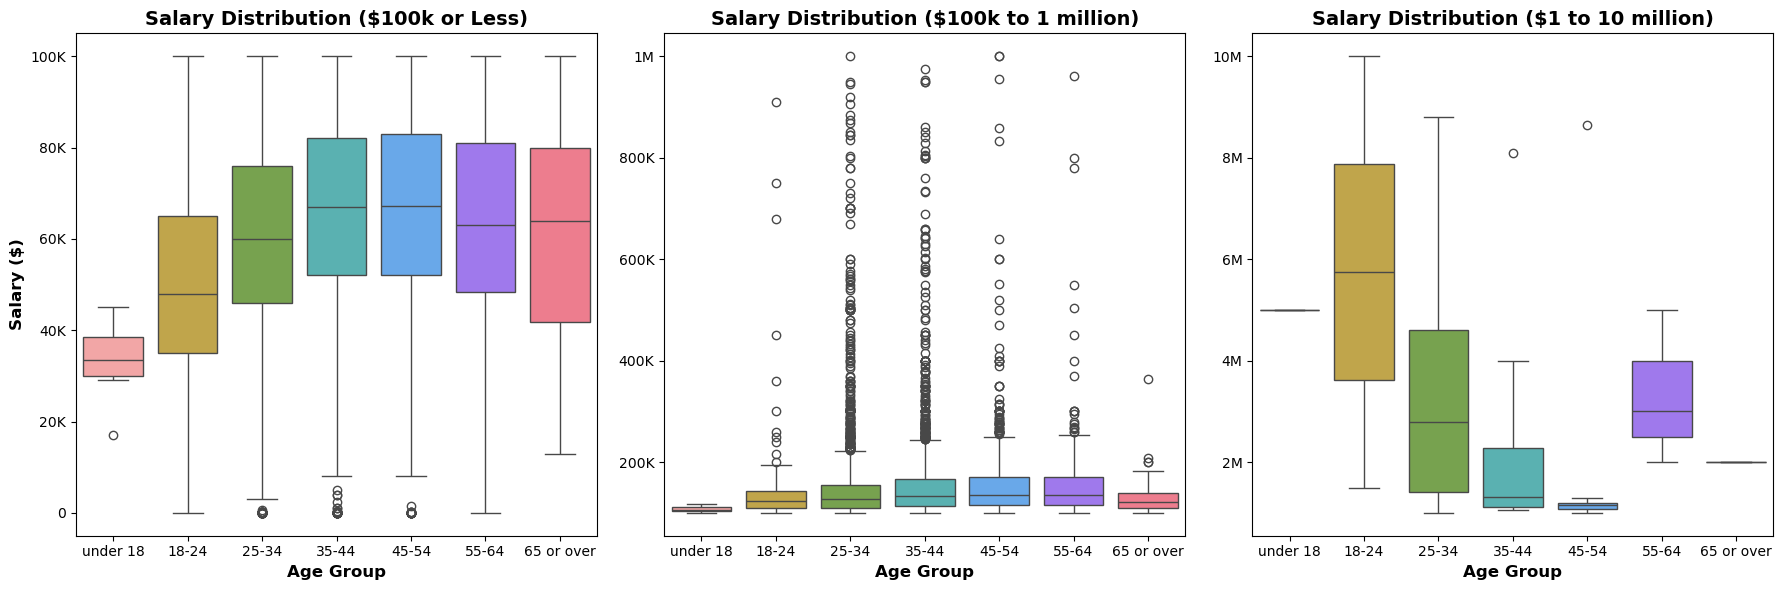

In [12]:
# Define custom color palette and custom order for display
custom_palette = ['#FF9999', '#D4AF37', '#76B041', '#4BC0C0', '#53A8FF', '#9966FF', '#FF6B81'] # colours for plot
age_order = ["under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65 or over"] # set in age order

# Create subsets for each salary range
emp2_less_100k = emp2[emp2['salary'] <= 100000] # less than 100K
emp2_100k_to_1m = emp2[(emp2['salary'] >= 100000) & (emp2['salary'] <= 1000000)] # 100K to 1million
emp2_1m_to_10m = emp2[(emp2['salary'] >= 1000000) & (emp2['salary'] <= 10000000)] # 1 to 10million

# Define a function to format y-axis ticks [ See disclaimer]
def format_y_ticks(x, pos):
    if x >= 1000000:
        return f'{x/1000000:.0f}M' # M = $Million
    elif x >= 1000:
        return f'{x/1000:.0f}K' # K = $1000
    else:
        return f'{x:.0f}' # less than 1K

# Create subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Salaries 100k or less
sns.boxplot(data=emp2_less_100k, x='age', y='salary', palette=custom_palette, order=age_order, ax=axes[0])
axes[0].yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
axes[0].set_title('Salary Distribution ($100k or Less)', fontsize=14, weight='bold')
axes[0].set_xlabel('Age Group', fontsize=12, weight='bold')
axes[0].set_ylabel('Salary ($)', fontsize=12, weight='bold')

# Plot 2: Salaries 100k to 1 million
sns.boxplot(data=emp2_100k_to_1m, x='age', y='salary', palette=custom_palette, order=age_order, ax=axes[1])
axes[1].yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
axes[1].set_title('Salary Distribution ($100k to 1 million)', fontsize=14, weight='bold')
axes[1].set_xlabel('Age Group', fontsize=12, weight='bold')
axes[1].set_ylabel('')

# Plot 3: Salaries 1 million to 10 million
sns.boxplot(data=emp2_1m_to_10m, x='age', y='salary', palette=custom_palette, order=age_order, ax=axes[2])
axes[2].yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
axes[2].set_title('Salary Distribution ($1 to 10 million)', fontsize=14, weight='bold')
axes[2].set_xlabel('Age Group', fontsize=12, weight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [13]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary.png', format='png')

<Figure size 640x480 with 0 Axes>

________________________________________________________________________________________________________________________________________

## 6. Top 20 salaries

[Disclaimer]: The code highlighted was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

In [14]:
import pandas as pd

# Define a formatting function for salary values [See disclaimer]
def format_salary(value):
    if value == 0:
        return '0'  # Explicitly show 0.00 as 0
    elif value >= 1000000:
        return f'{value / 1000000:.1f} million'  # Show as million
    elif value >= 1000:
        return f'{value / 1000:.0f}K'  # Show as K to represent $1000
    else:
        return f'{value:.2f}'  # Show with two decimal places for smaller values

# Find the top 20 salaries and format them
top_20_salaries = emp2.nlargest(20, 'salary')[['salary']]
top_20_salaries['salary'] = top_20_salaries['salary'].apply(format_salary)

# Find the lowest 20 salaries and format them
lowest_20_salaries = emp2.nsmallest(20, 'salary')[['salary']]
lowest_20_salaries['salary'] = lowest_20_salaries['salary'].apply(format_salary)

# Combine into a single table
combined_salaries = pd.DataFrame({
    'Top 20 Salaries': top_20_salaries['salary'].reset_index(drop=True),
    'Bottom 20 Salaries': lowest_20_salaries['salary'].reset_index(drop=True)
})

# Display the combined table
print(combined_salaries.to_string(index=False))  # Show as a formatted table

Top 20 Salaries Bottom 20 Salaries
 6000.1 million                  0
  870.0 million                  0
  180.0 million                  0
  120.0 million                  0
  102.0 million                  0
   43.8 million                  0
   38.0 million                  0
   36.0 million                  0
   27.0 million                  0
   20.8 million                  0
   11.5 million                  0
   10.0 million                  0
    8.8 million                  0
    8.6 million                  0
    8.3 million                  0
    8.1 million               1.00
    8.0 million               4.00
    6.0 million               5.00
    6.0 million              10.00
    6.0 million              15.00


________________________________________________________________________________________________________________________________________

In [15]:
# Reduce cardinality through selecting the top 10  industries from 'industry' and top 10 job titles in 'title' columns 
top_n_industries = emp2['industry'].value_counts().nlargest(10).index
top_n_titles = emp2['title'].value_counts().nlargest(10).index

print('Top 10 industries')
print(top_n_industries)
print('_____________________________________________________________________________________')
print('Top 10 job titles')
print(top_n_titles)
print('____________________________________________________________________________________________')

# If not in top 10 = other
emp3 = emp2.copy() # make a copy of original dataset
emp3['industry'] = np.where(emp3['industry'].isin(top_n_industries), emp3['industry'], 'Other') # if not in top 10 industries replace as other
emp3['title'] = np.where(emp3['title'].isin(top_n_titles), emp3['title'], 'Other') # if not in top 10 job titles replace as other

print(emp3.head()) # check it renders correctly

Top 10 industries
Index(['Computing or Tech', 'Education (Higher Education)', 'Nonprofits',
       'Health care', 'Government and Public Administration',
       'Accounting, Banking & Finance', 'Engineering or Manufacturing',
       'Marketing, Advertising & PR', 'Law', 'Business or Consulting'],
      dtype='object', name='industry')
_____________________________________________________________________________________
Top 10 job titles
Index(['Software Engineer', 'Project Manager', 'Director',
       'Senior Software Engineer', 'Librarian', 'Program Manager', 'Teacher',
       'Manager', 'Executive Assistant', 'Product Manager'],
      dtype='object', name='title')
____________________________________________________________________________________________
     age                       industry            title  salary  \
0  25-34   Education (Higher Education)            Other   55000   
1  25-34              Computing or Tech            Other   54600   
2  25-34  Accounting, Bankin

________________________________________________________________________________________________________________________________________

## 7. Visualizing salary distributions: insights across demographic and professional variables
[Disclaimer]: The code highlighted was supported by Microsoft Copilot, an AI-powered assistant to provide assistance in python code generation and debugging.

In [16]:
# Define the function to group salaries to 6 defined groups [See disclaimer]
def categorize_salary(salary):
    if pd.isna(salary):
        return np.nan
    elif salary <= 50000:
        return "0-50k"
    elif salary <= 100000:
        return "50-100k"
    elif salary <= 250000:
        return "100-250k"
    elif salary <= 500000:
        return "250-500k"
    elif salary <= 1000000:
        return "500k-1M"
    else:
        return ">1M"

# Add the salary group to the data frame using apply
emp3['salary_group'] = emp3['salary'].apply(categorize_salary)
print(emp3.head())

     age                       industry            title  salary  \
0  25-34   Education (Higher Education)            Other   55000   
1  25-34              Computing or Tech            Other   54600   
2  25-34  Accounting, Banking & Finance            Other   34000   
3  25-34                     Nonprofits  Program Manager   62000   
4  25-34  Accounting, Banking & Finance            Other   60000   

     experience     in_field       education      gender salary_group  
0     5-7 years    5-7 years   Master degree       Woman      50-100k  
1  8 - 10 years    5-7 years  College degree  Non-binary      50-100k  
2   2 - 4 years  2 - 4 years  College degree       Woman        0-50k  
3  8 - 10 years    5-7 years  College degree       Woman      50-100k  
4  8 - 10 years    5-7 years  College degree       Woman      50-100k  


#### **Define x.axis orders for plotting**

In [17]:
# Define the order of the x-axis labels based on salary ranges
salary_order = ["0-50k", "50-100k", "100-250k", "250-500k", "500k-1M", ">1M"]
emp3['salary_group'] = pd.Categorical(emp3['salary_group'], categories=salary_order, ordered=True)

# Set the order for the 'industry' variable
industry_order = ["Computing or Tech", "Education (Higher Education)", "Health care", "Nonprofits", "Other"]
emp3['industry'] = pd.Categorical(emp3['industry'], categories=industry_order, ordered=True)

# Set the order for the 'age' variable
age_order = ["under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65 or over"]
emp3['age'] = pd.Categorical(emp3['age'], categories=age_order, ordered=True)

# Set the order for the 'title' variable
title_order = ["Software Engineer", "Senior Software Engineer", "Project Manager", "Director", "Other"]
emp3['title'] = pd.Categorical(emp3['title'], categories=title_order, ordered=True)

# Set the order for the 'experience' variable
experience_order = ["1 year or less", "2-4 years", "5-7 years", "8-10 years", "11-20 years", "21-30 years", "31-40 years", "41 years or more"]
emp3['experience'] = pd.Categorical(emp3['experience'], categories=experience_order, ordered=True)

# Set the order for the 'in_field' variable
in_field_order = ["1 year or less", "2-4 years", "5-7 years", "8-10 years", "11-20 years", "21-30 years", "31-40 years", "41 years or more"]
emp3['in_field'] = pd.Categorical(emp3['in_field'], categories=in_field_order, ordered=True)

# Set the order for the 'education' variable
education_order = ["High School", "Some college", "College degree", "Master degree", "Professional degree", "PhD"]
emp3['education'] = pd.Categorical(emp3['education'], categories=education_order, ordered=True)

# Set the order for the 'gender' variable and combine categories
emp3['gender'] = emp3['gender'].replace("Prefer not to answer", "Other or prefer not to answer")
gender_order = ["Man", "Woman", "Non-binary", "Other or prefer not to answer"]
emp3['gender'] = pd.Categorical(emp3['gender'], categories=gender_order, ordered=True)

print(emp3.head())  # Check the first few rows to confirm the changes

     age                      industry  title  salary experience   in_field  \
0  25-34  Education (Higher Education)  Other   55000  5-7 years  5-7 years   
1  25-34             Computing or Tech  Other   54600        NaN  5-7 years   
2  25-34                           NaN  Other   34000        NaN        NaN   
3  25-34                    Nonprofits    NaN   62000        NaN  5-7 years   
4  25-34                           NaN  Other   60000        NaN  5-7 years   

        education      gender salary_group  
0   Master degree       Woman      50-100k  
1  College degree  Non-binary      50-100k  
2  College degree       Woman        0-50k  
3  College degree       Woman      50-100k  
4  College degree       Woman      50-100k  


________________________________________________________________________________________________________________________________________

### **7.1. Industry**

In [ ]:
# Plotting salary groups by industry
palette = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='industry', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Industry") 
plt.ylabel("Count")
plt.legend(title='Salary ($)')
plt.ylim(0, 4000)
plt.yticks(range(0, 4001, 500))
plt.title('Salary ($) by Industry', fontweight='bold')

plt.show()

An analysis of salary distribution across five industry sectors: Computing or Tech, Education (Higher Education), Health Care, Nonprofits, and Other. The Computing or Tech sector exhibits a notably diverse salary distribution. A substantial number of employees across various industries fall within the 50K to 100K salary range. Additionally, the "Other" category warrants attention due to its significant concentration of high-end salaries, indicating the existence of distinct salary frameworks that reflect the unique professional landscapes of each industry.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_industry.png', format='png', bbox_inches='tight')

________________________________________________________________________________________________________________________________________

### **7.2. Age**

In [1]:
# Plotting salary groups by age
palette = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='age', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Age") 
plt.ylabel("Count") 
plt.legend(title='Salary ($)')  
plt.ylim(0, 7000)
plt.yticks(range(0, 7001, 500))
plt.title('Salary ($) by Age', fontweight='bold')

# Plotting level of education by age
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='age', hue='education', palette=palette, alpha=0.7)
plt.xlabel("Age") 
plt.ylabel("Count") 
plt.legend(title='Education')  
plt.ylim(0, 7000)
plt.yticks(range(0, 7001, 500))
plt.title('Level of Education by Age', fontweight='bold')

plt.show()


NameError: name 'plt' is not defined

The examination of salary and educational attainment across various age groups indicates significant trends. Salary levels are highest among individuals aged 25 to 44, demonstrating the greatest diversity and potential for elevated earnings. In contrast, the younger demographic (ages 18 to 24) and the older population (ages 65 and over) are less represented in high-salary positions. Educational attainment is highest among individuals aged 25 to 44, with advanced degrees like Master's, Professional degrees, and PhDs concentrated in this group. This concentration indicates younger and older age groups show less educational diversity, likely due to varying access to educational opportunities and shifts in workforce demands.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_age.png', format='png')
plt.savefig('images/age_education.png', format='png')

________________________________________________________________________________________________________________________________________

### **7.3. Job Title**

In [ ]:
# Plotting salary groups by title
palette = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='title', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Job Title")  
plt.ylabel("Count")  
plt.legend(title='Salary ($)')  
plt.ylim(0, 14000)
plt.yticks(range(0, 14001, 1000))
plt.title('Salary ($) by Title', fontweight='bold')

plt.show()

The majority of individuals fall into the 'Other' category across all salary ranges, highlighting a lack of sufficient data for specific job titles such as Software Engineer, Senior Software Engineer, Project Manager, and Director. This predominance can obscure valuable insights from these job titles, weaken the analysis, and reduce clarity. Therefore, eliminating the `Title` variable may allow for a more focused examination of other variables that can provide richer insights without being overshadowed by the 'Other' category.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_title.png', format='png')

________________________________________________________________________________________________________________________________________

### **7.4. Industry Experience**

In [ ]:
# Plotting salary groups by experience
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='experience', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Experience") 
plt.ylabel("Count")  
plt.legend(title='Salary ($)')  
plt.ylim(0, 2600)
plt.yticks(range(0, 2601, 500))
plt.title('Salary ($) by Experience', fontweight='bold') 

# Plotting age groups by experience
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='age', hue='experience', palette=palette, alpha=0.7)
plt.xlabel("Age Group") 
plt.ylabel("Count")  
plt.legend(title='Experience')  
plt.ylim(0, 4500)
plt.yticks(range(0, 4501, 500))
plt.title('Age by Experience', fontweight='bold') 
plt.show()

Experience plays a crucial role in determining salary levels, with individuals who have more experience generally commanding higher wages. As professionals gain experience, a greater proportion transitions into higher salary brackets, such as those earning between $100,000 and $250,000. Conversely, less experienced individuals tend to remain in lower income ranges. 

Individuals between the ages of 25 and 44 typically command higher salaries due to their considerable experience. In contrast, younger individuals under the age of 24 generally earn less. Meanwhile, those aged 55 and older often possess substantial experience but may opt to retire or reduce their working hours, leading to variations in salary levels.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_experience.png', format='png')
plt.savefig('images/age_by_experience.png', format='png')

________________________________________________________________________________________________________________________________________

### **7.5. Years in Field**

In [ ]:
# Plotting salary groups by in_field
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='in_field', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("In-Field") 
plt.ylabel("Count")  
plt.legend(title='Salary ($)')  
plt.ylim(0, 3500)
plt.yticks(range(0, 3501, 500))
plt.title('Salary ($) by years in Field', fontweight='bold')  

# Plotting salary groups by in_field
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='industry', hue='in_field', palette=palette, alpha=0.7)
plt.xlabel("Industry") 
plt.ylabel("Count")  
plt.legend(title='In-Field')  
plt.ylim(0, 4000)
plt.yticks(range(0, 4001, 500))
plt.title('Years In Field by Industry', fontweight='bold')  
plt.show()

The analysis reveals significant insights regarding salary and professional experience across industries. Notably, the most pronounced salary distributions are observed within the 2-4 and 5-7 years in-field ranges, with peak salary potential during early to mid-career stages. However, high-end salary brackets become less common as experience increases. Additionally, the Computing or Tech and "Other" industries demonstrate the most diverse experience distributions, while a concentration of professionals with 1 to 10 years of experience is evident across most sectors. In contrast, longer tenure categories of 31-40 years and above remain relatively sparse.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_in_field.png', format='png')
plt.savefig('images/in_field by industry.png', format='png')

________________________________________________________________________________________________________________________________________

### **7.6. Education level**

In [ ]:
# Plotting salary groups by education
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='education', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Education") 
plt.ylabel("Count")  
plt.legend(title='Salary ($)') 
plt.ylim(0, 7000)
plt.yticks(range(0, 7001, 1000))
plt.title('Salary ($) by Education', fontweight='bold') 

plt.show()

Individuals with a College, Master’s, or Professional degree, specifically at the doctoral level, typically have access to a broad range of salary options, including high-paying opportunities. In contrast, those who hold a high school diploma or completed some college education generally face more limited and lower salary ranges.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_education.png', format='png')

________________________________________________________________________________________________________________________________________

### **7.7. Gender**

In [ ]:
# Plotting salary groups by gender
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='gender', hue='salary_group', palette=palette, alpha=0.7)
plt.xlabel("Gender") 
plt.ylabel("Count")  
plt.legend(title='Salary ($)') 
plt.ylim(0, 11000)
plt.yticks(range(0, 11001, 1000))
plt.title('Salary ($) by Gender', fontweight='bold')  

# Plotting salary groups by gender
plt.figure(figsize=(15, 6))
sns.countplot(data=emp3, x='age', hue='gender', palette=palette, alpha=0.7)
plt.xlabel("Age") 
plt.ylabel("Count")  
plt.legend(title='Gender') 
plt.ylim(0, 10000)
plt.yticks(range(0, 10001, 1000))
plt.title('Age by Gender', fontweight='bold')  
plt.show()

Men and women demonstrate the most significant and diverse salary distributions, while the non-binary and "Other or prefer not to answer" categories have notably less representation. There are considerable variations in salary ranges across different gender groups. Regarding age, the most prominent distributions are found in the 25-34 and 35-44 age ranges, with men and women dominating all groups. The non-binary and "Other" categories show minimal representation in the age demographics, and the workforce is primarily concentrated in mid-career age brackets.

In [ ]:
# Save the plot as a file (e.g., PNG)
plt.savefig('images/salary_by_gender.png', format='png')
plt.savefig('images/age_by_gender.png', format='png')

________________________________________________________________________________________________________________________________________

## 8. Summary

The document presents a detailed preliminary data analysis of the EmpData.csv dataset, which encapsulates survey responses designed to explore the employability and career trajectories of students enrolled in Data Science programs. Utilizing various Python libraries such as pandas, numpy, matplotlib, and seaborn, the analysis adheres to the Knowledge Discovery in Databases (KDD) process. This structured approach encompasses data manipulation, visualization, and statistical analysis to derive meaningful insights from the dataset.

Initially, the analysis outlines the key variables present in the dataset including demographic and professional factors critical for assessing employability, such as age, salary, industry, job title, experience, education, and gender. 

Data cleaning and preparation process begins with loading the dataset and systematically addressing any missing values. Specifically, gaps in categorical columns are filled with the mode, ensuring data integrity while preserving the dataset's representativeness. Additionally, to focus the analysis on critical variables directly relevant to employability, irrelevant columns, such as those related to demographic context (like race and location) and financial details (like surplus or currency) are excluded. This careful curation enhances the clarity and focus of the subsequent analyses.

Among the visualizations provide insights into how age may correlate with earning potential. Similarly, count plots are generated to assess salary distributions within various industries, notably highlighting that the Computing or Tech sector showcases diverse salary patterns compared to others. The analysis also delves into how experience influences salary; findings indicate that peak salary potential is typically observed during early to mid-career stages.

A pronounced salary variability across different age cohorts suggests that age significantly correlates with earning potential. The data illustrate that individuals within the Computing or Tech industry typically enjoy the highest salaries, with a strong concentration of high earnings within this sector. Additionally, educational attainment plays a crucial role; individuals with college or advanced degrees generally experience broader and more lucrative salary ranges in comparison to those with lower educational credentials. The analysis also touches on potential gender disparities, revealing that gender may influence compensation outcomes in the labor market.

In conclusion, the analysis highlights essential insights regarding the interplay among salary, age, industry, education, and gender, thereby establishing a foundation for future research and action in the field.